<h1 style = "color: purple; text-align: center;font-family: Poppins; font-weight: 800;">Autonomous Model Reliability Engine (AMRE)</h1>

**Autonomous Model Reliability Engine (AMRE)
A production-grade self-healing ML system that continuously monitors data quality, detects feature and concept drift, diagnoses root causes using explainability methods, and automatically triggers model retraining or recalibration based on a policy-driven decision engine.**

In [40]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">1. Create a synthetic data</h2>

In [41]:
np.random.seed(42)

In [42]:
n = 5000

age = np.random.randint(19,60,n).round()
base_income = 8000
age_effect = -10 * (age - 45)**2 + 55000
raw_income = (base_income + age_effect + np.random.lognormal(9, 0.5, n))
income = (raw_income - raw_income.mean()) / raw_income.std()
income = (income * 20000 + 60000).round(2)
savings_rate = np.random.uniform(0.05, 0.3, n)
debt_ratio = np.random.uniform(0.1, 0.6, n)
noise = np.random.normal(0,0.03,n)
age_effect = -10 * (age - 40)**2 + 500
age_effect = (age_effect - age_effect.mean()) / age_effect.std()
purchase_power = (
    (income * (1 - savings_rate - debt_ratio))
    + (age_effect * 5000)
    + noise *4000).round(2)

In [43]:
data = {
    "age":age,
    "income":income,
    "savings_rate":savings_rate.round(2),
    "debt_ratio":debt_ratio.round(2),
    "purchase_power":purchase_power}

In [44]:
df = pd.DataFrame(data)
df

,age,income,savings_rate,debt_ratio,purchase_power
0,57,52651.67,0.07,0.42,21029.01
1,47,57833.38,0.22,0.43,23525.62
2,33,91580.17,0.22,0.52,27732.16
3,26,42537.86,0.22,0.39,14752.88
4,39,50845.70,0.29,0.33,24869.56
...,...,...,...,...,...
4995,37,58160.52,0.21,0.32,32361.67
4996,23,44873.35,0.28,0.41,8222.87
4997,41,59597.96,0.25,0.14,42214.66
4998,48,84507.79,0.10,0.57,30994.45


In [45]:
from sklearn.preprocessing import MinMaxScaler

In [46]:
scaler = MinMaxScaler(feature_range=(1, 100))
purchasing_power = scaler.fit_transform(df[["purchase_power"]])
df["purchasing_power"] = pd.DataFrame(purchasing_power.round(2), columns=["purchasing_power"])
df

,age,income,savings_rate,debt_ratio,purchase_power,purchasing_power
0,57,52651.67,0.07,0.42,21029.01,22.28
1,47,57833.38,0.22,0.43,23525.62,24.03
2,33,91580.17,0.22,0.52,27732.16,26.97
3,26,42537.86,0.22,0.39,14752.88,17.89
4,39,50845.70,0.29,0.33,24869.56,24.96
...,...,...,...,...,...,...
4995,37,58160.52,0.21,0.32,32361.67,30.20
4996,23,44873.35,0.28,0.41,8222.87,13.33
4997,41,59597.96,0.25,0.14,42214.66,37.09
4998,48,84507.79,0.10,0.57,30994.45,29.25


In [47]:
df.to_csv("purchase_power.csv")

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">2. Exploratory Analysis</h2>

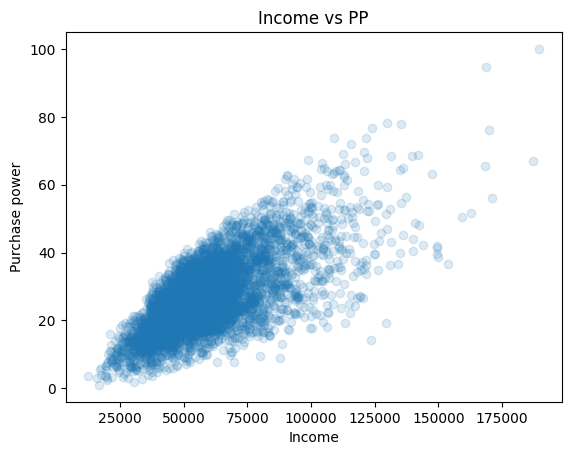

In [48]:
plt.scatter(df["income"], df["purchasing_power"], alpha=0.15)
plt.xlabel("Income")
plt.ylabel("Purchase power")
plt.title("Income vs PP")
plt.show()

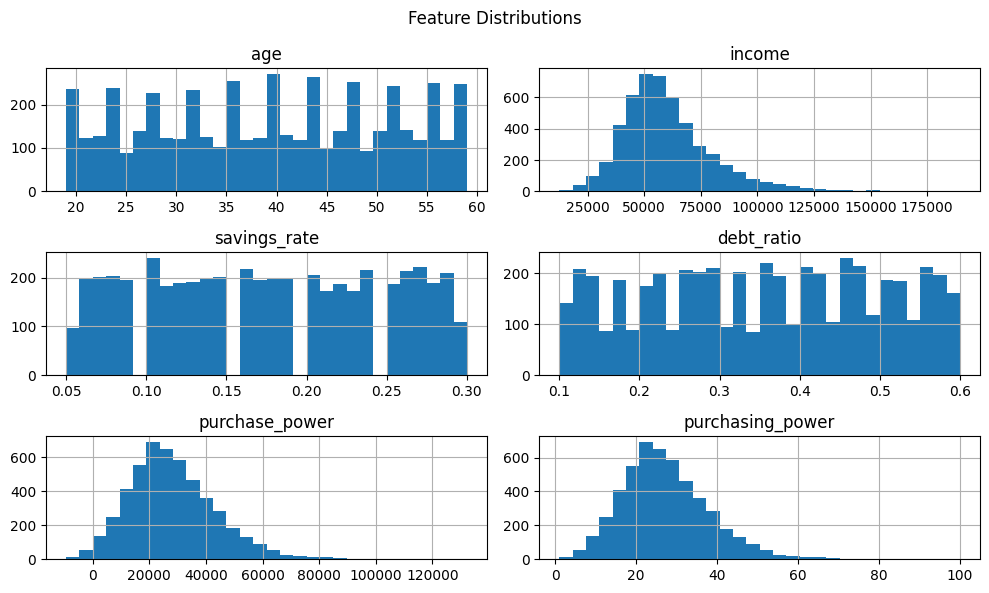

In [49]:
df.hist(figsize=(10,6), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

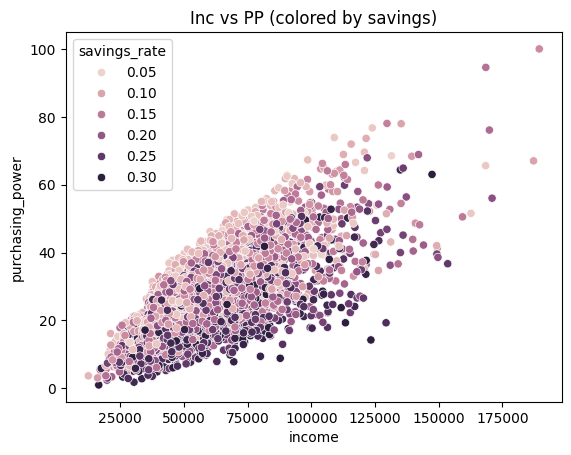

In [50]:
sns.scatterplot(data=df, x="income", y="purchasing_power", hue="savings_rate")
plt.title("Inc vs PP (colored by savings)")
plt.show()

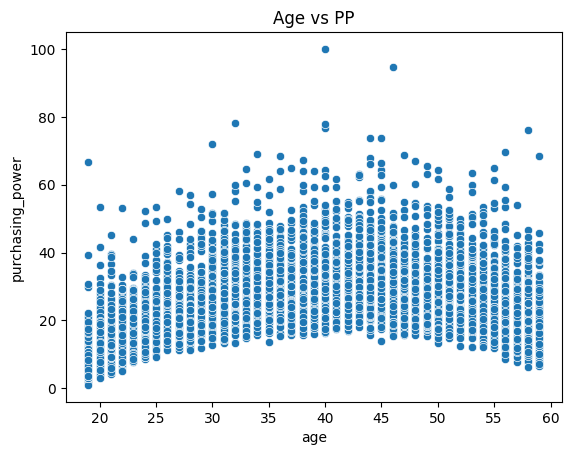

In [51]:
sns.scatterplot(data=df, x="age", y="purchasing_power")
plt.title("Age vs PP")
plt.show()

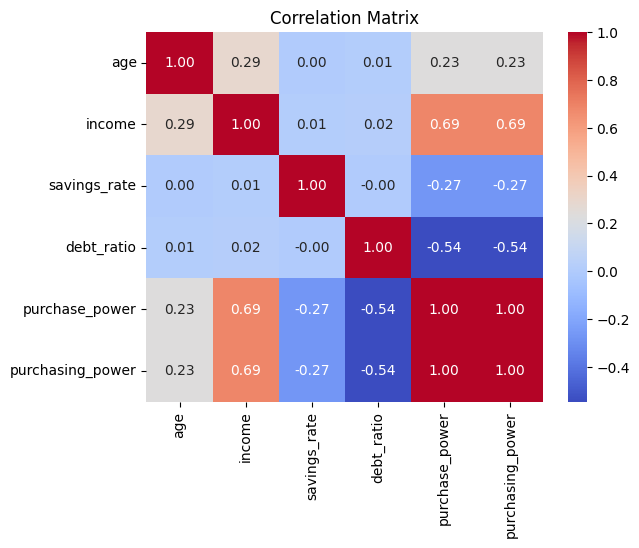

In [52]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix.png")
plt.show()

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">3. Baseline Model Training</h2>

In [53]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [54]:
X = df.drop(["purchase_power", "purchasing_power"],axis=1)
y = df.purchasing_power

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.9)

In [56]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [57]:
y_pred = model.predict(X_test)

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">4. Baseline Model Performance</h2>

In [58]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score,max_error

In [59]:
mean_squared_error(y_test, y_pred) 

18.584808808304974

In [60]:
mean_absolute_error(y_test, y_pred) 

3.4770415114822777

In [61]:
r2_score(y_test, y_pred) 

0.8296317945756015

In [62]:
max_error(y_test, y_pred) 

19.66728541345201

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">4. Data Drift</h2>

In [63]:
income += np.random.normal(15000,8000,n)
age += np.random.randint(2,6,n)
savings_rate += np.random.normal(0.05,0.07,n)
debt_ratio += np.random.normal(0.07,0.012,n)
purchase_power = (
    (income * (1 - savings_rate - debt_ratio))
    + (age_effect * 5000)
    + noise *4000).round(2)

In [64]:
data_d = {
    "age":age,
    "income":income,
    "savings_rate":savings_rate.round(2),
    "debt_ratio":debt_ratio.round(2),
    "purchase_power":purchase_power}

In [65]:
df_d = pd.DataFrame(data_d)
df_d

,age,income,savings_rate,debt_ratio,purchase_power
0,62,58251.953447,0.07,0.50,19276.61
1,49,78568.259851,0.30,0.49,20070.82
2,37,105478.292994,0.23,0.57,25457.33
3,28,59654.198133,0.35,0.44,10446.65
4,41,58921.610741,0.25,0.41,25566.93
...,...,...,...,...,...
4995,42,72342.533480,0.26,0.39,29876.39
4996,25,51461.660604,0.14,0.49,13380.62
4997,46,74145.735916,0.22,0.21,47298.61
4998,52,93209.415960,0.10,0.65,26550.46


In [66]:
scaler = MinMaxScaler(feature_range=(1, 100))
purchasing_power = scaler.fit_transform(df_d[["purchase_power"]])
df_d["purchasing_power"] = pd.DataFrame(purchasing_power.round(2), columns=["purchasing_power"])
df_d

,age,income,savings_rate,debt_ratio,purchase_power,purchasing_power
0,62,58251.953447,0.07,0.50,19276.61,25.13
1,49,78568.259851,0.30,0.49,20070.82,25.66
2,37,105478.292994,0.23,0.57,25457.33,29.21
3,28,59654.198133,0.35,0.44,10446.65,19.30
4,41,58921.610741,0.25,0.41,25566.93,29.29
...,...,...,...,...,...,...
4995,42,72342.533480,0.26,0.39,29876.39,32.13
4996,25,51461.660604,0.14,0.49,13380.62,21.24
4997,46,74145.735916,0.22,0.21,47298.61,43.64
4998,52,93209.415960,0.10,0.65,26550.46,29.94


<h2 style = "color: red;font-family: Poppins; font-weight: 500;">5. Drift Detection</h2>

In [67]:
def compare_kde(df, drifted_df, col):
    plt.figure()
    
    sns.kdeplot(df[col], label="Original", fill=True)
    sns.kdeplot(drifted_df[col], label="Drifted", fill=True)
    
    plt.title(f"KDE Comparison: {col}")
    plt.legend()
    plt.show()

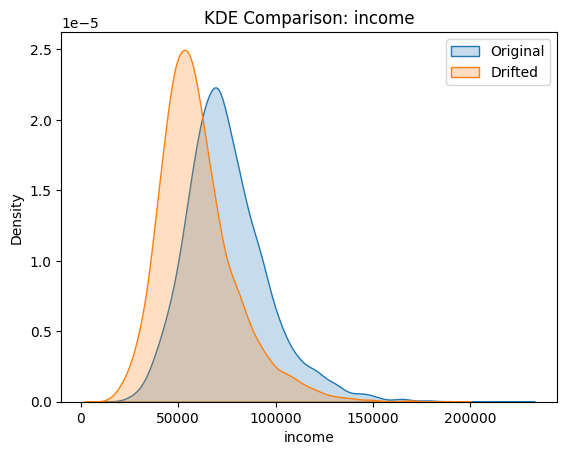

In [68]:
compare_kde(df_d, df, "income")

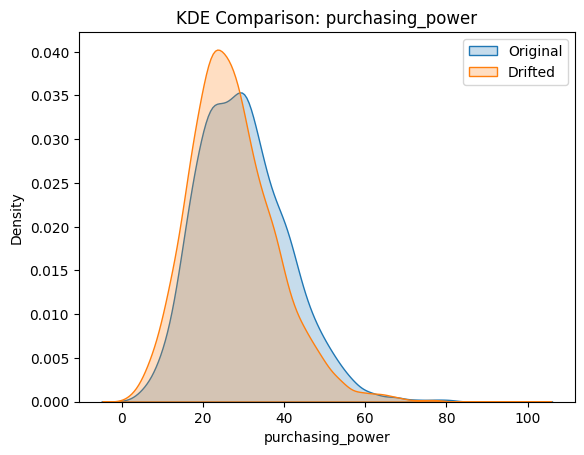

In [73]:
compare_kde(df_d, df, "purchasing_power")

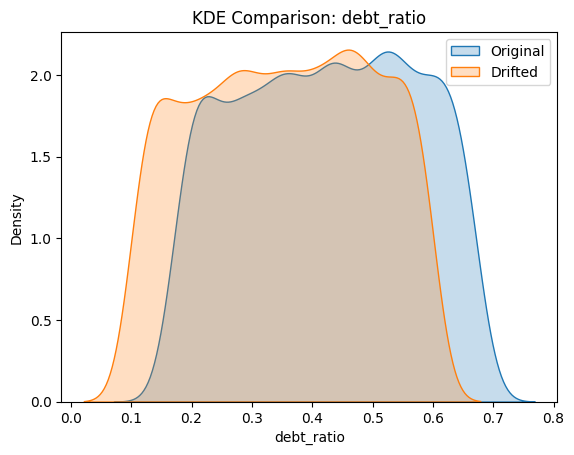

In [77]:
compare_kde(df_d, df, "debt_ratio")

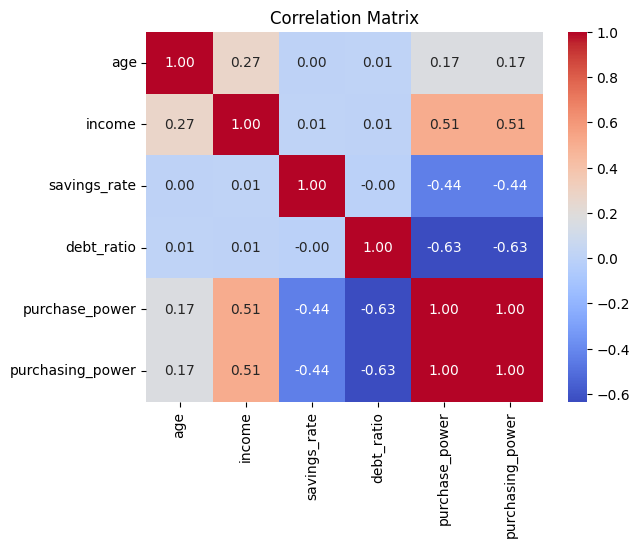

In [82]:
sns.heatmap(df_d.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig("correlation_matrix_d.png")
plt.show()

In [85]:
drift_score = np.mean(np.abs(df[["age","income", "savings_rate", "debt_ratio"]].mean() 
               - df_d[["age","income", "savings_rate", "debt_ratio"]].mean()))
drift_score

np.float64(3757.1874502750998)

<h2 style = "color: red;font-family: Poppins; font-weight: 500;">6. Decision Engine</h2>